<a href="https://colab.research.google.com/github/anyuanay/INFO213/blob/main/INFO213_Week6_logisticRegression_regularization_lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 213: Data Science Programming 2
___

### Week 6: Logistic Regression and Regularization
___


**Agenda:**
- Overfitting and Regularization

# Tackling overfitting via regularization
- What is the mysterious parameter $C$ in `LogisticRegression(C=100.0, penalty="l2", random_state=1, solver='lbfgs')`?
- The parameter $C$ that is implemented for the `LogisticRegression` class in scikit-learn is the inverse of regularization parameter, $\lambda$.

# Convert Non-Linear Relationships to Linear Models
- One trick we can use to adapt linear relationships to nonlinear relationships between variables is to transform the data according to *polynomial functions*.

- The idea is to add polynomial terms to the linear function. For example, given a single-demensional linear function:
$$
y = w_0 + w_1 x$$
we can extend it to a multi-dimensional function:
$$
y = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_3 + \cdots
$$
where $x_1=x$, $x_2=x^2$, $x_3=x^3$, and so on, from the single-dimensional input $x$.

- Notice that this is *still a linear model* - the linearity refers to the fact that the coefficients $w_n$ never multiply or divide each other.

- What we have effectively done is taken our one-dimensional $x$ values and projected them into a higher dimension, so that a linear fit can fit more complicated relationships between $x$ and $y$.

## Geneate non-linear data with scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def plot_with_decision_boundary(X, y, poly, clf, title):

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))


    # Transform meshgrid
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict on meshgrid points
    if poly:
        grid_poly = poly.transform(grid)
        Z = clf.predict(grid_poly)
    else:
        Z = clf.predict(grid)

    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

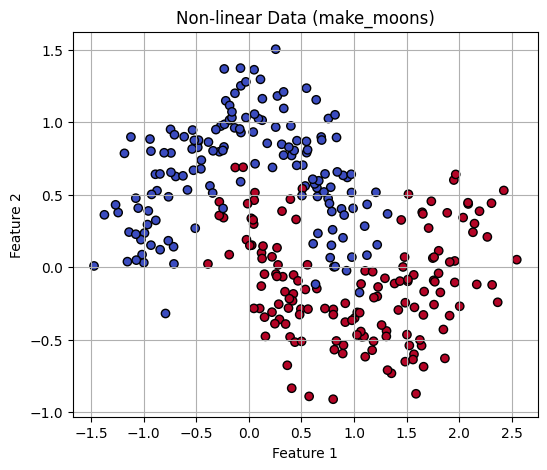

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate non-linearly separable data
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Visualize the data
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Non-linear Data (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
X.shape, y.shape

((300, 2), (300,))

## Train a logistic regression classifier without polynomial terms

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_std = sc.fit_transform(X)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_moons = LogisticRegression()

In [ ]:
lr_moons.fit(X_std, y)

LogisticRegression()

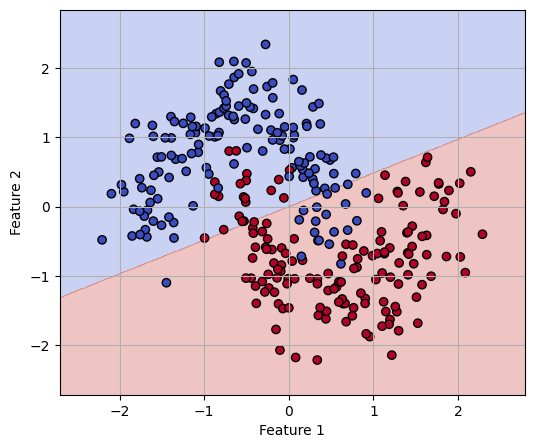

In [ ]:
plot_with_decision_boundary(X_std, y, None, lr_moons, "")

### Add polynomial terms with scikit-learn polynomial basis functions

- The polynomial projection is useful enough that it is built into Scikit-Learn, using the ``PolynomialFeatures`` transformer

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# Transform the input for moons' data with polynomial of degree 3
moons_poly = PolynomialFeatures(3, include_bias=False)
X_std_poly = moons_poly.fit_transform(X_std)
X_std.shape, X_std_poly.shape

((300, 2), (300, 9))

### List the Polynomial Terms with Degree 3 (No Bias Term)

Assume a feature matrix $ X $ with two input features $ x_1 $ and $ x_2 $. Applying:

$$
\texttt{PolynomialFeatures(degree=3, include_bias=False).fit_transform(X)}
$$

generates all polynomials up to degree 3 (excluding the bias term), i.e., all combinations of $ x_1 $ and $ x_2 $ such that:

$$
x_1^a x_2^b \quad \text{where} \quad a + b \leq 3, \quad a, b \geq 0
$$

#### Resulting Terms

- Degree 1:
  $$
  x_1, \quad x_2
  $$

- Degree 2:
  $$
  x_1^2, \quad x_1 x_2, \quad x_2^2
  $$

- Degree 3:
  $$
  x_1^3, \quad x_1^2 x_2, \quad x_1 x_2^2, \quad x_2^3
  $$

In [ ]:
lr_moons_poly = LogisticRegression()
lr_moons_poly.fit(X_std_poly, y)

LogisticRegression()

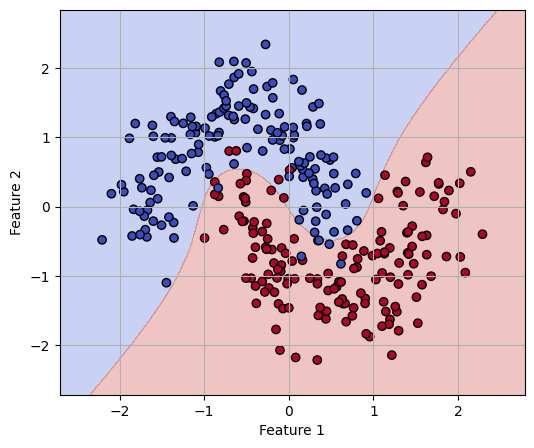

In [ ]:
plot_with_decision_boundary(X_std, y, moons_poly, lr_moons_poly, "")

## Overfitting Model

- The introduction of polynomial terms makes the model much more flexible, but it also can very quickly lead to over-fitting

- For example, if we choose the polynomial function with very high degree, the model may not look good.

In [ ]:
moons_poly_high = PolynomialFeatures(40, include_bias=False)
X_std_poly_high = moons_poly_high.fit_transform(X_std)
X_std_poly_high.shape

(300, 860)

In [ ]:
lr_moons_poly_high = LogisticRegression(max_iter=5000)
lr_moons_poly_high.fit(X_std_poly_high, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

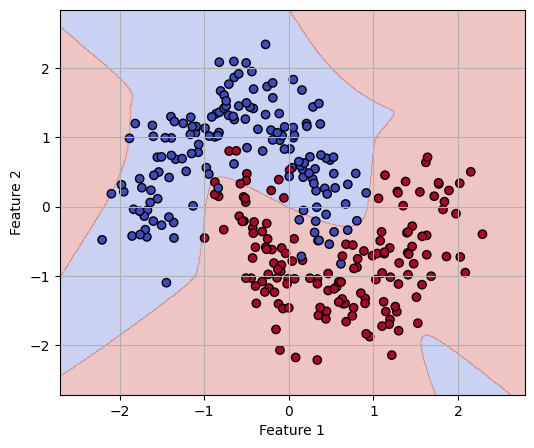

In [ ]:
plot_with_decision_boundary(X_std, y, moons_poly_high, lr_moons_poly_high, "")

### Overfitting and underfitting
- Overfitting is a common problem in machine learning, where a model performs well on training data but does not generalize well to unseen data (test data).
- If a model suffers from overfitting, we also say that the model has a **high variance**, which can be caused by having too many parameters, leading to a model that is too complex given the underlyingdata.
- Similarly, our model can also suffer
from underfitting (**high bias**), which means that our model is not complex enough to capture the pattern in the training data well and therefore also suffers from low performance on unseen data.
- To be robust, a model should maintain an appropriate balance between bias and variance.

<img src="https://i.imgur.com/ei07ag6.png" width=800>

## Regularization
- One way of finding a good bias-variance tradeoff is to tune the complexity of the model via regularization.
- Regularization is a very useful method for handling collinearity (high correlation among features), filtering out noise from data, and eventually preventing overfitting.
- The concept behind regularization is to introduce additional information (bias) to penalize extreme parameter (weight) values.


## Ridge (L2) Regulariztion
- The most common form of regularization is so-called $L2$ regularization (sometimes alsocalled $L2$ shrinkage or weight decay or Ridge regularization), which can be written as follows:
\begin{equation}
    \frac{\lambda}{2}\lvert\lvert \mathbf{w} \rvert\rvert^2=\frac{\lambda}{2}\Sigma_j w_j^2, j=1...m
\end{equation}
- $\lambda$ is called regularization parameter.
- For regularization to work properly, features should be normalized in the same scale.
- The loss function is: $J(\mathbf{w}) = .... + \frac{\lambda}{2}\Sigma_j w_j^2$, $j=1...m$.

### Apply regularization to the complex logistic regression model on moons data

```
# Transform the input for moons' data with polynomial of degree 3
moons_poly_high = PolynomialFeatures(40, include_bias=False)
X_std_poly_high = moons_poly_high.fit_transform(X_std)
X_std_poly_high.shape
```

```
lr_moons_poly_high_reg = LogisticRegression(C=0.00001, penalty="l2", max_iter=5000)
lr_moons_poly_high_reg.fit(X_std_poly_high, y)
```

```
plot_with_decision_boundary(X_std, y, moons_poly_high, lr_moons_poly_high_reg, "")
```

### Test different regularizations

In [ ]:
def plot_with_decision_boundary_ax(X, y, poly, model, title, ax):

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))


    # Transform meshgrid
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict on meshgrid points
    if poly:
        grid_poly = poly.transform(grid)
        Z = clf.predict(grid_poly)
    else:
        Z = clf.predict(grid)

    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Plot the data points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')

    # Set the plot title and axis labels
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


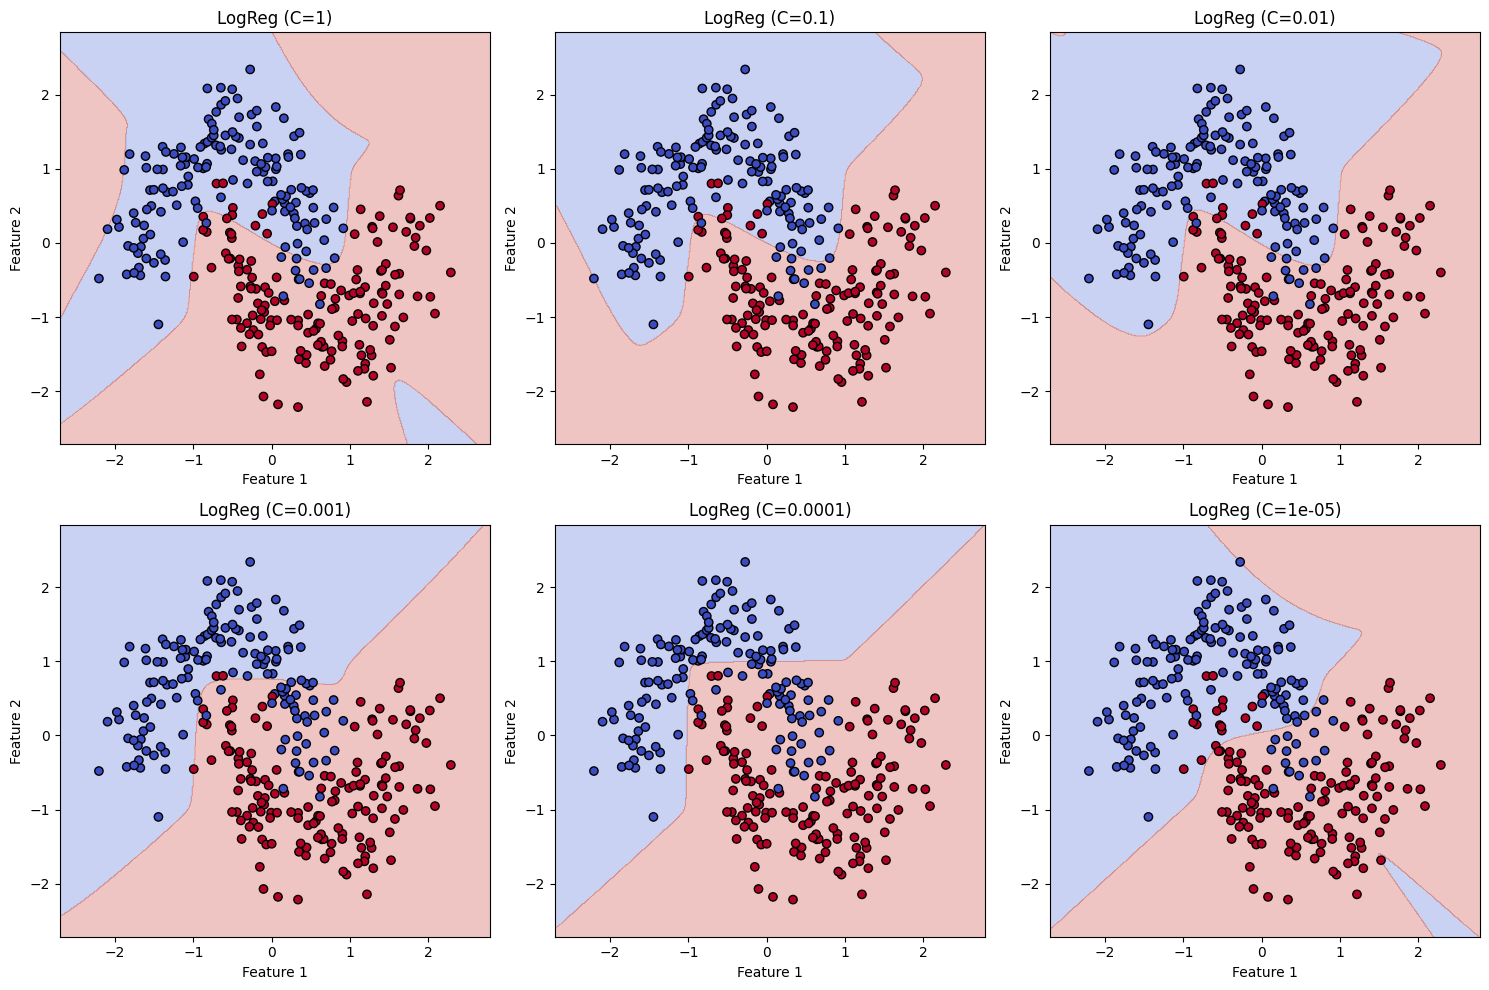

In [ ]:
C_values = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
models = []
titles = []

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, C in enumerate(C_values):
    clf = LogisticRegression(C=C, solver='lbfgs', penalty="l2", max_iter=10000)
    clf.fit(X_std_poly_high, y)
    models.append(clf)
    titles.append(f"LogReg (C={C})")

    #plot_with_decision_boundary(X_std, y, moons_poly_high, clf, f"LogReg (C={C})")
    plot_with_decision_boundary_ax(X_std, y, moons_poly_high, clf, f"LogReg (C={C})", axes[i])

plt.tight_layout()  # Adjust subplot parameters for a tight layout.
plt.show()

### Update the weights of logistic regression with regularization
- Given input $\mathbf{x}=\{x_j^{(i)}\}$, $i=1...n, j=1...m$, and labels $\mathbf{y}=\{y^{(i)}\}$, where $y^{(i)}\in[0, 1]$, $i=1...n$.
- Initialize weights $\mathbf{w}=\{w_j\}$, $j=0...m$
- Compute $z^{(i)}=\mathbf{w}^{T}\mathbf{x}^{(i)}=w_0x_0^{(i)}+w_1x_1^{(i)}+...+w_mx_m^{(i)}$
- Compute $\bar{y}^{(i)}=\phi(z^{(i)})=\frac{1}{1+e^{-z^{(i)}}}$
- Calculate the loss: \begin{equation}
J(\mathbf{w}) = -\Sigma_i(y^{(i)} log(\bar{y}^{(i)})+(1-y^{(i)}) log(1-\bar{y}^{(i)}))+ \frac{\lambda}{2}\Sigma_j w_j^2, j=1...m
\end{equation}
- Update the weights by taking a step in the opposite direction of the gradient, $\nabla J(\mathbf{w})$ of our cost function $J(\mathbf{w})$:
 - $\mathbf{w} := \mathbf{w} + \Delta \mathbf{w}$, where $\Delta \mathbf{w}= - \eta \nabla J(\mathbf{w})$, specifically,
 \begin{equation}
\nabla J_j=\frac{\partial J}{\partial w_j} = - \Sigma_i(y^{(i)}-\phi(z^{(i)}))x_j^{(i)} + \lambda w_j
\end{equation}
 - Update $w_0$ without regularization:
\begin{equation}
\Delta w_0 = - \eta \frac{\partial J}{\partial w_0} = \eta \Sigma_i(y^{(i)}-\phi(z^{(i)}))x_0^{(i)}
\end{equation}
 - Update the rest of $w_j$ with regularization:
\begin{equation}
\Delta w_j = - \eta \frac{\partial J}{\partial w_j} = \eta (\Sigma_i(y^{(i)}-\phi(z^{(i)}))x_j^{(i)} - \lambda w_j)
\end{equation}

## Lasso regression ($L_1$ regularization)

- Another very common type of regularization is known as lasso, and involves penalizing the sum of absolute values (1-norms) of regression coefficients:

\begin{equation}
    \lambda\lvert\lvert \mathbf{w} \rvert\rvert=\lambda\Sigma_j |w_j|, j=1...m
\end{equation}


- Though this is conceptually very similar to ridge regression, the results can differ surprisingly: for example, due to geometric reasons lasso regression tends to favor *sparse models* where possible: that is, it preferentially sets model coefficients to exactly zero.

- We can see the behavior of L1 regularization in following figures:

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


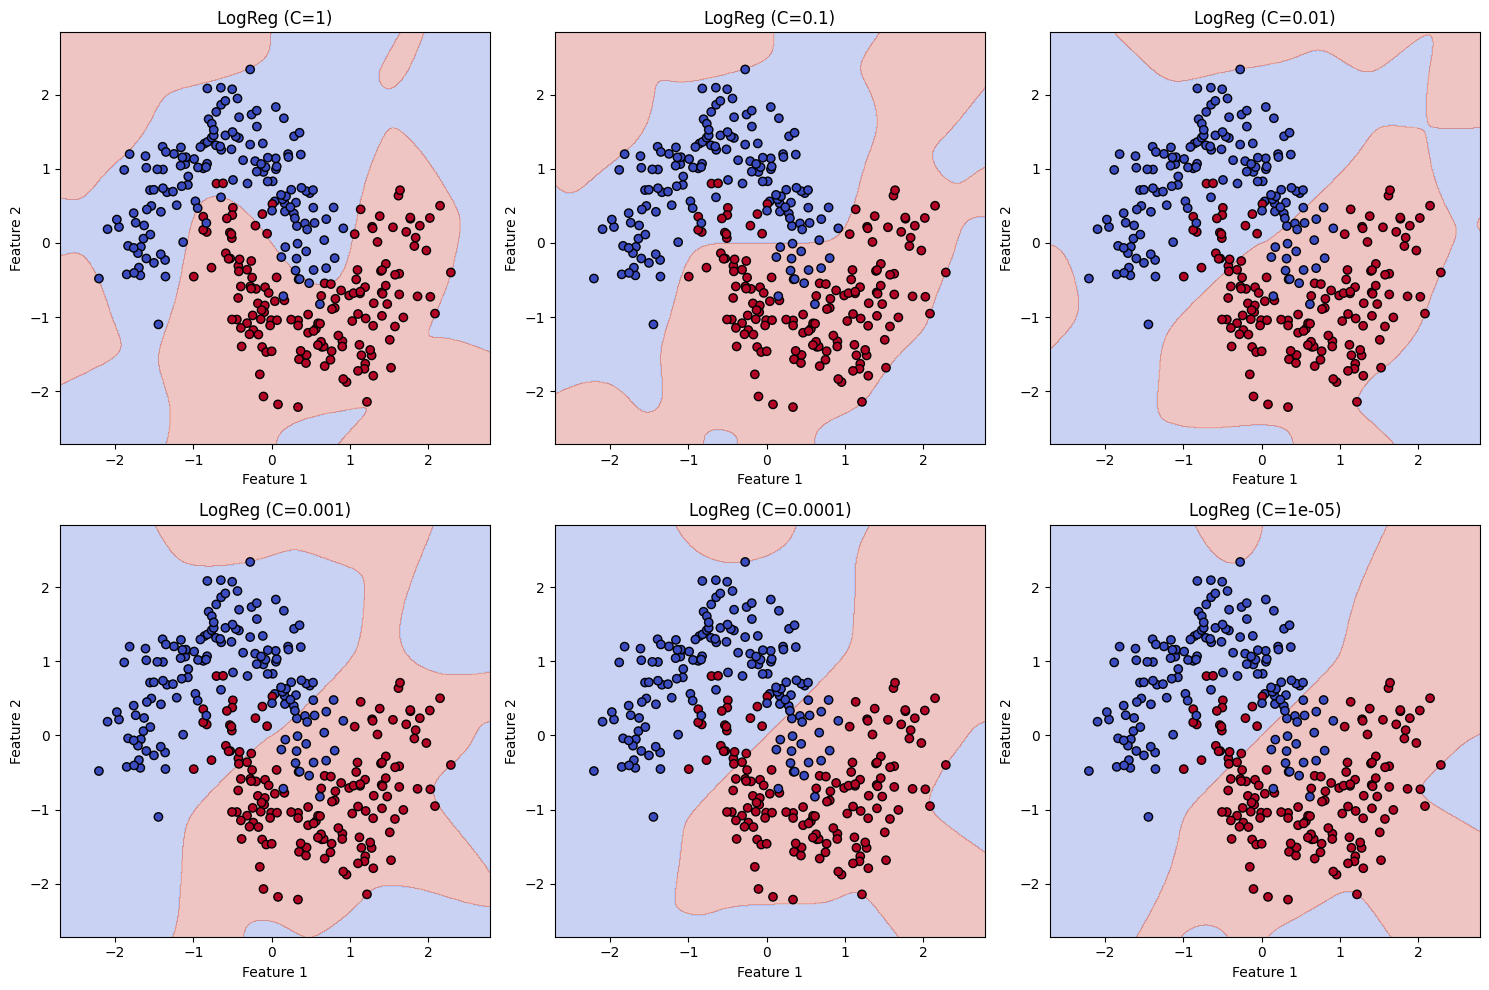

In [ ]:
C_values = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
models = []
titles = []

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, C in enumerate(C_values):
    clf = LogisticRegression(C=C, solver='liblinear', penalty="l1", max_iter=1000)
    clf.fit(X_std_poly_high, y)
    models.append(clf)
    titles.append(f"LogReg (C={C})")

    #plot_with_decision_boundary(X_std, y, moons_poly_high, clf, f"LogReg (C={C})")
    plot_with_decision_boundary_ax(X_std, y, moons_poly_high, clf, f"LogReg (C={C})", axes[i])

plt.tight_layout()  # Adjust subplot parameters for a tight layout.
plt.show()

# Core Idea: Same Goal, Different Strategy

### Both Ridge (L2) and Lasso (L1) add a penalty to the loss:

- Ridge (L2) penalty:
\begin{equation}
    \frac{\lambda}{2}\lvert\lvert \mathbf{w} \rvert\rvert^2=\frac{\lambda}{2}\Sigma_j w_j^2, j=1...m
\end{equation}
    - The loss function is: $J(\mathbf{w}) = .... + \frac{\lambda}{2}\Sigma_j w_j^2$, $j=1...m$.

- Lasso (L1) penalty:
\begin{equation}
    \lambda\lvert\lvert \mathbf{w} \rvert\rvert=\lambda\Sigma_j |w_j|, j=1...m
\end{equation}
    - The loss function is: $J(\mathbf{w}) = .... + \lambda\Sigma_j |w_j|$, $j=1...m$.

### Interpretation:

- Ridge penalizes large weights strongly (quadratically).
- Lasso penalizes all weights equally (linearly).

### Geometric Intuition (Why behavior differs):

- Ridge (L2):
    - constraint region = circle / sphere.
    - smooth, rarely hits axes, weights shrink but rarely become zero.
    - shrinks, share the credit, change the magnitude.
- Lasso (L1):
    - constraint region = diamond.
    - sharp corners, solution often lands on axes, exact zeros.
    - selects, pick a winner, change the structure.

### When to use which in practice:

- Use Ridge when:
    - Many features contribute a little.
    - Features are highly correlated.
    - You care about prediction accuracy, not interpretability.
    - For example: Image pixels, Sensor data.

- Use Lasso when:
    - You suspect only a few features matter.
    - You want automatic feature selection.
    - Model interpretability matters.
    - For example: Text classification (many irrelevant words), Genomics (few important genes).


### Optimization Differences:
- Ridge (L2): Smooth, differentiable,  Easy to optimize (gradient-based); For example, lbfgs.
- Lasso (L1): Not differentiable at 0, Requires specialized methods (e.g., coordinate descent); For example, liblinear.


### In Summary:

- Step 1: What do you want?
    - Better prediction $\rightarrow$ start with Ridge.
    - Simpler model $\rightarrow$ try Lasso.
- Step 2: Check data
    - Highly correlated features $\rightarrow$ Ridge.
    - Many irrelevant features $\rightarrow$ Lasso.


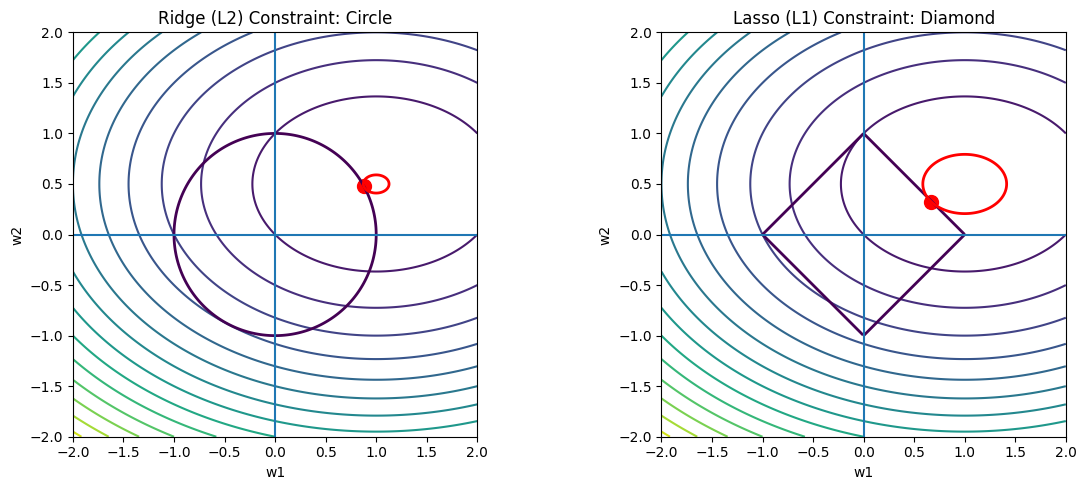

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid
w1 = np.linspace(-2, 2, 400)
w2 = np.linspace(-2, 2, 400)
W1, W2 = np.meshgrid(w1, w2)

# Define constraints
ridge = W1**2 + W2**2          # L2 norm (circle)
lasso = np.abs(W1) + np.abs(W2)  # L1 norm (diamond)

# Define a simple quadratic loss (ellipse)
# Shifted so minimum is not at (0,0)
loss = (W1 - 1)**2 + 2*(W2 - 0.5)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Ridge (L2)
# -------------------------
ax = axes[0]

# Plot loss contours
ax.contour(W1, W2, loss, levels=15)

# Plot constraint boundary
ax.contour(W1, W2, ridge, levels=[1], linewidths=2)

# Mask points inside constraint
mask = ridge <= 1

# Find minimum loss within region
masked_loss = np.where(mask, loss, np.inf)

idx = np.unravel_index(np.argmin(masked_loss), loss.shape)
w1_opt = W1[idx]
w2_opt = W2[idx]

ax.scatter(w1_opt, w2_opt, color='red', s=100)

opt_loss = loss[idx]

ax.contour(W1, W2, loss, levels=[opt_loss], colors='red', linewidths=2)

ax.set_title("Ridge (L2) Constraint: Circle")
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.axhline(0)
ax.axvline(0)
ax.set_aspect('equal')

# -------------------------
# Lasso (L1)
# -------------------------
ax = axes[1]

# Plot loss contours
ax.contour(W1, W2, loss, levels=15)

# Plot constraint boundary
ax.contour(W1, W2, lasso, levels=[1], linewidths=2)

# ---- FIND OPTIMUM ----
mask_lasso = lasso <= 1
masked_loss_lasso = np.where(mask_lasso, loss, np.inf)

idx_lasso = np.unravel_index(np.argmin(masked_loss_lasso), loss.shape)
w1_lasso = W1[idx_lasso]
w2_lasso = W2[idx_lasso]

# Plot optimal point
ax.scatter(w1_lasso, w2_lasso, color='red', s=100)

# Plot tangent contour
opt_loss_lasso = loss[idx_lasso]
ax.contour(W1, W2, loss, levels=[opt_loss_lasso], colors='red', linewidths=2)


ax.set_title("Lasso (L1) Constraint: Diamond")
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.axhline(0)
ax.axvline(0)
ax.set_aspect('equal')

# Example solution point (manually approximated)
# ax.scatter(0.8, 0.3, s=100, marker='x')

plt.tight_layout()
plt.show()

# Retrieval Practice